<a href="https://colab.research.google.com/github/srisham7/Homework-1---Mariana-Sisniegas-Hinojosa/blob/main/HW1_Mariana_Sisniegas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Dataset A

##Import Libraries

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [82]:
#Pytoch
import torch
import torch.nn as nn

## Data loading

In [83]:
!pip install ucimlrepo

In [84]:
from ucimlrepo import fetch_ucirepo

iris = fetch_ucirepo(id=53)

X = iris.data.features
y = iris.data.targets.values.flatten()

print(X.head())

   sepal length  sepal width  petal length  petal width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2


##Visualization of Raw Data

In [85]:
# LabelEncoder translated categories into numbers  and StandardScaler to normalized our data scales.
from sklearn.preprocessing import StandardScaler, LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)  # y_encoded will be a numerical array


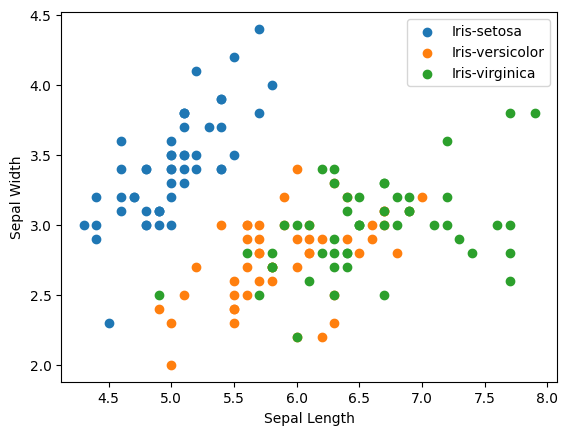

In [86]:
#alias for our target variable
y_values = y_encoded

for class_value in np.unique(y_values):
  class_name = le.classes_[class_value]

# we filter the feature set 'X' to pick only the rows that belong to the current class.
  plt.scatter(
        X.loc[y_values == class_value].iloc[:, 0],
        X.loc[y_values == class_value].iloc[:, 1],
        label=class_name
    )

#finalizing the visualization
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend()
plt.show()

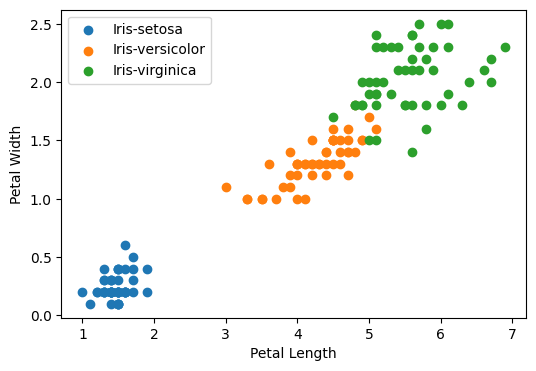

In [87]:
plt.figure(figsize=(6, 4))

for i, clase in enumerate(np.unique(y_values)):
    label_name = le.classes_[clase]
    plt.scatter(
        X.iloc[y_values == clase, 2],
        X.iloc[y_values == clase, 3],
        label=label_name
    )


plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.show()

##Train/test split

In [88]:
#extract specific columns ("petal length" and "petal width")
X = X[["petal length", "petal width"]]

# convert pandas objects into raw NumPy arrays
X_array = X.values
y_array = y

In [89]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
#use StandardScaler to transform features so they have a mean of 0 and a standard deviation of 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_array) # Usamos X_array (pétalos)


# Divide our scaled features and encoded labels into training (80%) and testing (20%).
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=4)


###Convert data to Pytorch tensors

In [90]:
# convert our NumPy arrays (X_train, X_test) into pytorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

#Convert to tensors of type 'long'
y_train = torch.tensor(y_train.astype(int), dtype=torch.long)
y_test = torch.tensor(y_test.astype(int), dtype=torch.long)

##Model definition

In [91]:
#create a class that inherits from 'nn.Module'
class LogisticRegression(nn.Module):

    def __init__(self):
        super(LogisticRegression, self).__init__()
# Input size = 2 (petal length, petal width)
 # Output size = 3 (Setosa, Versicolor, Virginica)
        self.linear = nn.Linear(2,3)
#define how the input 'x' travels through the model.
    def forward(self, x):
        return self.linear(x)


model = LogisticRegression()

##Training Loop

In [92]:
import torch.optim as optim
# 'CrossEntropyLoss'  for multi-class classification and SGD (Stochastic Gradient Descent) to update our model's weights.

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

#iterate through the training data 1000 times
epochs = 1000

for epoch in range(epochs):
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()  #clear gradients
    loss.backward()  #compute gradients
    optimizer.step()  #update weights

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 10/1000, Loss: 0.8801
Epoch 20/1000, Loss: 0.7188
Epoch 30/1000, Loss: 0.6327
Epoch 40/1000, Loss: 0.5740
Epoch 50/1000, Loss: 0.5296
Epoch 60/1000, Loss: 0.4941
Epoch 70/1000, Loss: 0.4648
Epoch 80/1000, Loss: 0.4401
Epoch 90/1000, Loss: 0.4187
Epoch 100/1000, Loss: 0.4001
Epoch 110/1000, Loss: 0.3836
Epoch 120/1000, Loss: 0.3689
Epoch 130/1000, Loss: 0.3556
Epoch 140/1000, Loss: 0.3436
Epoch 150/1000, Loss: 0.3327
Epoch 160/1000, Loss: 0.3227
Epoch 170/1000, Loss: 0.3135
Epoch 180/1000, Loss: 0.3049
Epoch 190/1000, Loss: 0.2971
Epoch 200/1000, Loss: 0.2897
Epoch 210/1000, Loss: 0.2829
Epoch 220/1000, Loss: 0.2765
Epoch 230/1000, Loss: 0.2705
Epoch 240/1000, Loss: 0.2649
Epoch 250/1000, Loss: 0.2596
Epoch 260/1000, Loss: 0.2546
Epoch 270/1000, Loss: 0.2499
Epoch 280/1000, Loss: 0.2454
Epoch 290/1000, Loss: 0.2412
Epoch 300/1000, Loss: 0.2371
Epoch 310/1000, Loss: 0.2333
Epoch 320/1000, Loss: 0.2297
Epoch 330/1000, Loss: 0.2262
Epoch 340/1000, Loss: 0.2229
Epoch 350/1000, Loss: 0

## Evaluation metrics

In [93]:
model.eval()  #freezes layers

with torch.no_grad():  #tells PyTorch not to store gradients, saving memory

    outputs = model(X_test)

    _, predicted = torch.max(outputs, 1)

In [94]:
# compare predictions with ground truth (y_test)
accuracy = (predicted == y_test).sum().item() / y_test.size(0)

print("Accuracy:", accuracy)

Accuracy: 0.9333333333333333


###Generating the confusion matrix
A matrix comparing predicted labels vs. true labels from the test set, this reveals  how many predictions were and specifically where the model struggles

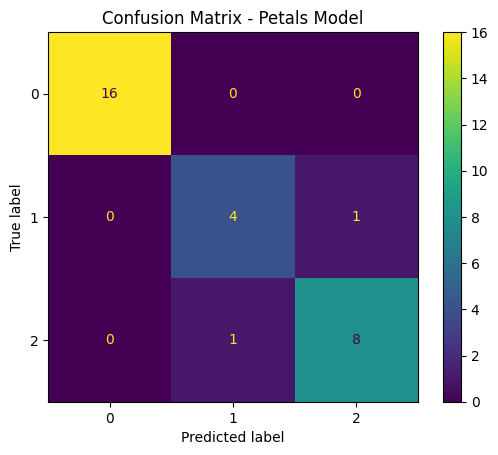

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test.numpy(), predicted.numpy())

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

##Decision Boundary Visualization

In [96]:
from sklearn.preprocessing import StandardScaler

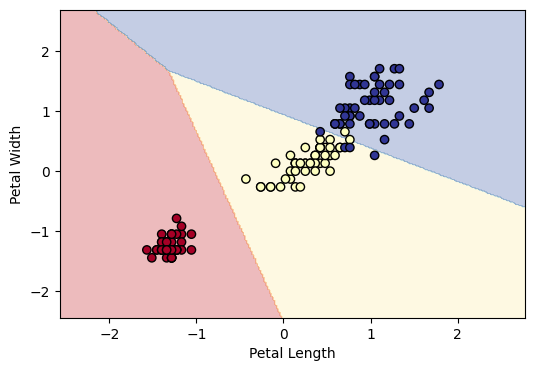

In [97]:
#create a dense grid of points covering the entire feature space.
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# predict the species for every point on the grid.
grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.tensor(grid_points, dtype=torch.float32)

model.eval()
with torch.no_grad():
    outputs = model(grid_tensor)
    _, Z_preds = torch.max(outputs, 1)
    Z = Z_preds.reshape(xx.shape).numpy()

# overlay the original data points on the decision regions.
plt.figure(figsize=(6, 4))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_encoded, edgecolors='k', cmap=plt.cm.RdYlBu)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

#Dataset B


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.tree import DecisionTreeClassifier
import sklearn.tree as tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [3]:
#Pytoch
import torch
import torch.nn as nn

##Data loading

In [1]:
!pip install medmnist

In [4]:
import medmnist
from medmnist import BreastMNIST

In [25]:
import torchvision.transforms as transforms
#convert image data to pytorch tensors
transform = transforms.Compose([
    transforms.ToTensor()
])

In [24]:
#Update your dataset loading to use this pipeline
train_dataset = BreastMNIST(split='train', transform=transform, download=True)
test_dataset = BreastMNIST(split='test', transform=transform, download=True)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Train samples: 546
Test samples: 156


##Visualization of raw data
*   0 → Benign
*   1 → Malignant



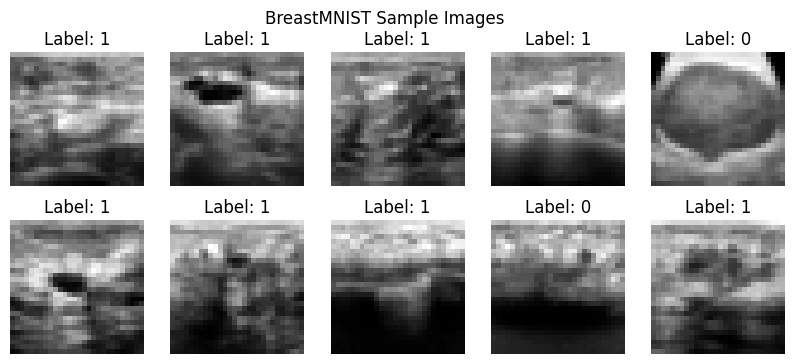

In [26]:
#display a sample grid of BreastMNIST images and their corresponding labels.
fig, axes = plt.subplots(2,5, figsize=(10,4))

for i, ax in enumerate(axes.flatten()):
    img, label = train_dataset[i]

    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label.item()}")
    ax.axis("off")

plt.suptitle("BreastMNIST Sample Images")
plt.show()

##Train/Test Split

In [8]:
#convert images to NumPy arrays
X_train = []
y_train = []

for img, label in train_dataset:
  #.numpy() converts tensor to array, .flatten() collapses dimensions
    X_train.append(img.numpy().flatten())
    y_train.append(label.item())

X_train = np.array(X_train)
y_train = np.array(y_train)

print(X_train.shape)

(546, 784)


In [28]:
X_test = []
y_test = []

for img, label in test_dataset:

    X_test.append(img.numpy().flatten())
    y_test.append(label.item())

X_test = np.array(X_test)
y_test = np.array(y_test)


print("X_test shape:", X_test.shape)

X_test shape: (156, 784)


##Model Definition

In [10]:
from sklearn.tree import DecisionTreeClassifier

In [12]:
#create a decision tree model instance with a predefined maximum depth.
breastTree = DecisionTreeClassifier(
    max_depth=5,
    random_state=4
)

## Training Loop

In [29]:
#the algorithm constructs the decision tree based  (X_train) and (y_train)
breastTree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=4)

##Evaluation metrics

In [30]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [32]:
#predict the class labels
y_pred = breastTree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7884615384615384


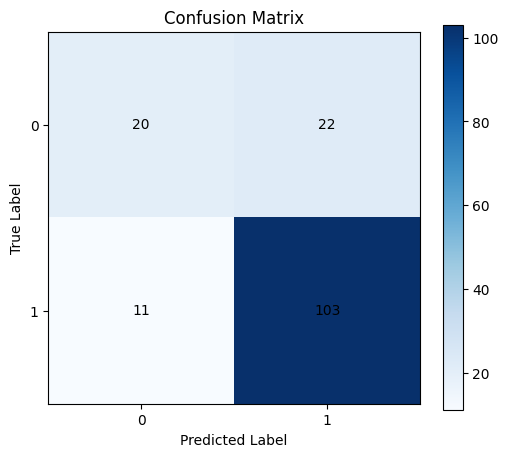

In [37]:
cm = confusion_matrix(y_test, y_pred)

#render the matrix as a heatmap using Matplotlib.
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add text annotations for clarity
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="black")

plt.xticks(np.arange(2))
plt.yticks(np.arange(2))

plt.colorbar()
plt.show()

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.48      0.55        42
           1       0.82      0.90      0.86       114

    accuracy                           0.79       156
   macro avg       0.73      0.69      0.70       156
weighted avg       0.78      0.79      0.78       156



###Decision Tree Visualization

In [35]:
from sklearn import tree

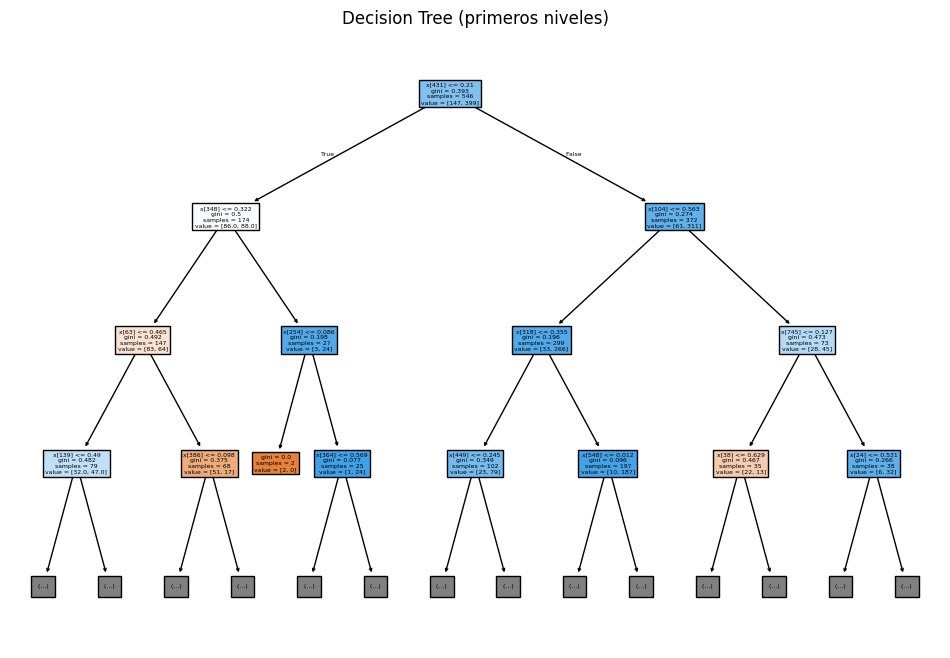

In [36]:
plt.figure(figsize=(12,8))

tree.plot_tree(
    breastTree,
    max_depth=3,
    filled=True
)

plt.show()

##Decision Boundary Visualization

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_2d = pca.fit_transform(X_train)
X_test_2d = pca.transform(X_test)

In [21]:
tree_boundary = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_boundary.fit(X_train_2d, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

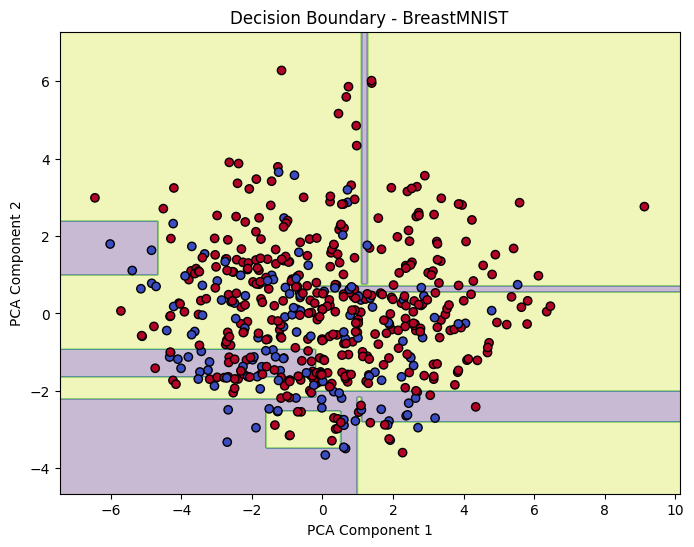

In [22]:
x_min, x_max = X_train_2d[:,0].min() - 1, X_train_2d[:,0].max() + 1
y_min, y_max = X_train_2d[:,1].min() - 1, X_train_2d[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)
Z = tree_boundary.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X_train_2d[:,0],
    X_train_2d[:,1],
    c=y_train,
    cmap="coolwarm",
    edgecolor="k"
)

plt.title("Decision Boundary - BreastMNIST")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

#Critical Reflection
Answer the following: What does it mean for a model to “generalize” in this toy setting? What factors could make a result appear good but actually be meaningless (e.g., data leakage, very small test set, unstable metric, overfitting to noise)?

"Generalize" means that a model has the ability to learn patterns from the training data and apply them correctly to new, unseen data.
Some factors that could make a result appear good are: Data Leakage: This happens if the model accidentally "peeks" at the test data during training. Overfitting to Noise: This occurs when a model becomes too complex. If we let the tree grow too deep, it starts memorizing unimportant details in our images rather than the real patterns of a tumor. Tiny Test Sets: If you only test your model on a very small group . It’s not a reliable measure of how the model will perform in the real world. Imbalanced Data: In the second data, you often have way more healthy samples than sick ones. If a model predicts Healthy 100% of the time, it might look 90% accurate, but it is completely useless because it fails to catch the actual disease.